# Experiment 4 - Supervised Learning
Linear Regression, Polynomial Regression, Random Forest, and SVM

## 1.1 Regression

### 1.1.1 Generating Examples

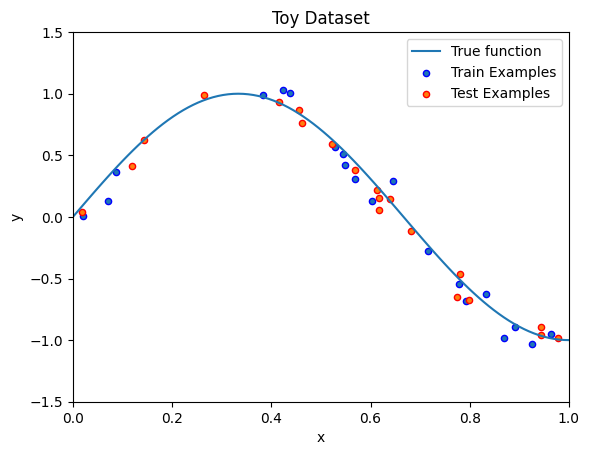

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def true_fun(X):
    return np.sin(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 40
X = np.random.rand(n_samples)
X_train = np.sort(X[:n_samples//2])
y_train = true_fun(X_train) + np.random.randn(n_samples//2) * 0.1
X_test = np.sort(X[n_samples//2:])
y_test = true_fun(X_test) + np.random.randn(n_samples//2) * 0.1

x = np.linspace(0, 1, 100)
plt.plot(x, true_fun(x), label="True function")
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Train Examples")
plt.scatter(X_test, y_test, edgecolor="r", s=20, label="Test Examples")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-1.5, 1.5))
plt.legend(loc="best")
plt.title("Toy Dataset")
plt.show()

### 1.1.2 Linear Regression

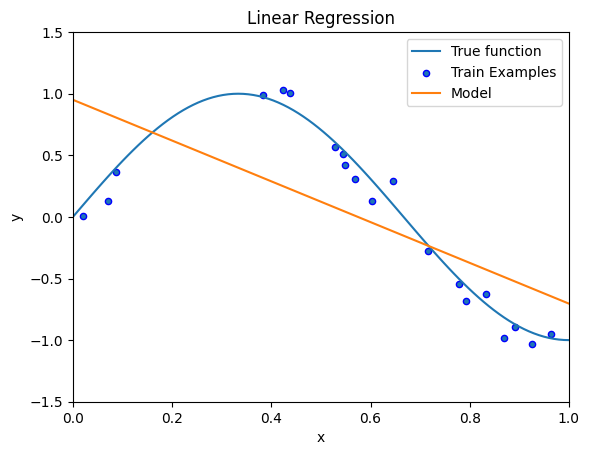

In [19]:
from sklearn.linear_model import LinearRegression

linear_regression = LinearRegression()
linear_regression.fit(X_train[:, np.newaxis], y_train)

x = np.linspace(0, 1, 100)
plt.plot(x, true_fun(x), label="True function")
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Train Examples")
plt.plot(x, linear_regression.predict(x[:, np.newaxis]), label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-1.5, 1.5))
plt.legend(loc="best")
plt.title("Linear Regression")
plt.show()

### Task 1: MSE of Linear Regression on Test Set

In [20]:
from sklearn.metrics import mean_squared_error

y_pred_linear = linear_regression.predict(X_test[:, np.newaxis])
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression MSE on Test Set: {mse_linear:.4f}")

Linear Regression MSE on Test Set: 0.1736


### 1.1.3 Polynomial Regression

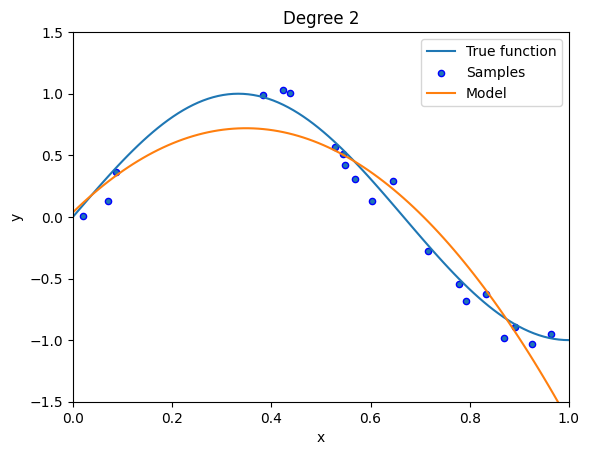

In [21]:
from sklearn.preprocessing import PolynomialFeatures

# Degree 2
polynomial_features = PolynomialFeatures(2, include_bias=True)
q_model = LinearRegression()
q_model.fit(polynomial_features.fit_transform(X_train[:, np.newaxis]), y_train)

x = np.linspace(0, 1, 100)
plt.plot(x, true_fun(x), label="True function")
plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Samples")
plt.plot(x, q_model.predict(polynomial_features.fit_transform(x[:, np.newaxis])), label="Model")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim((0, 1))
plt.ylim((-1.5, 1.5))
plt.legend(loc="best")
plt.title("Degree 2")
plt.show()

### Task 2: Polynomial Regression - Degree 4 and 15

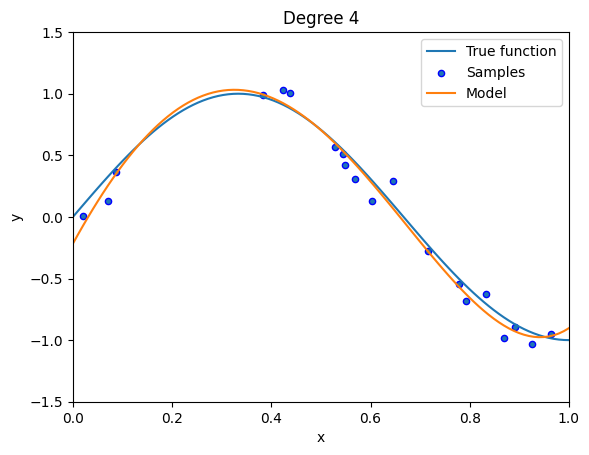

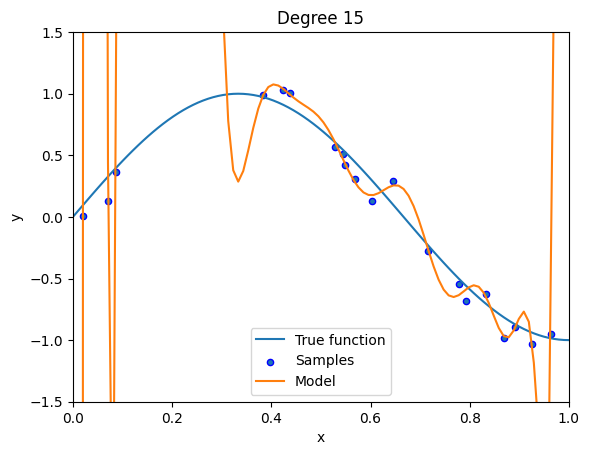

In [22]:
x = np.linspace(0, 1, 100)

for degree in [4, 15]:
    poly_feat = PolynomialFeatures(degree, include_bias=True)
    model = LinearRegression()
    model.fit(poly_feat.fit_transform(X_train[:, np.newaxis]), y_train)

    plt.plot(x, true_fun(x), label="True function")
    plt.scatter(X_train, y_train, edgecolor="b", s=20, label="Samples")
    plt.plot(x, model.predict(poly_feat.fit_transform(x[:, np.newaxis])), label="Model")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-1.5, 1.5))
    plt.legend(loc="best")
    plt.title(f"Degree {degree}")
    plt.show()

### Task 3: MSE Comparison - Degrees 2, 4, 15

In [23]:
ritmodels = {}
print(f"{'Degree':<10} {'Train MSE':<15} {'Test MSE':<15}")
print("-" * 40)

for degree in [2, 4, 15]:
    poly_feat = PolynomialFeatures(degree, include_bias=True)
    model = LinearRegression()
    model.fit(poly_feat.fit_transform(X_train[:, np.newaxis]), y_train)

    train_mse = mean_squared_error(y_train, model.predict(poly_feat.fit_transform(X_train[:, np.newaxis])))
    test_mse  = mean_squared_error(y_test,  model.predict(poly_feat.fit_transform(X_test[:, np.newaxis])))

    models[degree] = (model, poly_feat)
    print(f"{degree:<10} {train_mse:<15.4f} {test_mse:<15.4f}")

print("\nConclusion: The model with the lowest TEST MSE is the best generalizer.")
print("Degree 15 likely overfits (low train MSE but high test MSE).")

Degree     Train MSE       Test MSE       
----------------------------------------
2          0.0440          0.0563         
4          0.0093          0.0046         
15         0.0013          503.6525       

Conclusion: The model with the lowest TEST MSE is the best generalizer.
Degree 15 likely overfits (low train MSE but high test MSE).


---
## 1.2 Classification

### 1.2.1 Generating Examples

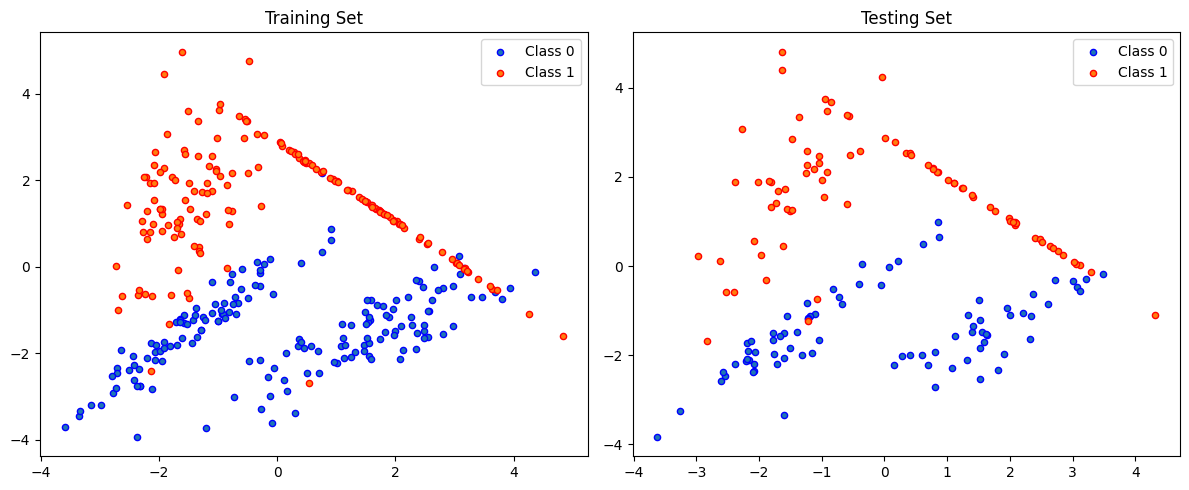

In [24]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=500, n_features=2, n_classes=2,
    n_informative=2, n_redundant=0,
    n_clusters_per_class=2, random_state=0,
    shuffle=True, class_sep=1.5
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

colors = ["b", "r"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.set_title("Training Set")
ax2.set_title("Testing Set")

for c in np.unique(y_train):
    ax1.scatter(
        [X_train[i, 0] for i in np.where(y_train == c)[0]],
        [X_train[i, 1] for i in np.where(y_train == c)[0]],
        edgecolor=colors[c], s=20, label=f"Class {c}"
    )
    ax2.scatter(
        [X_test[i, 0] for i in np.where(y_test == c)[0]],
        [X_test[i, 1] for i in np.where(y_test == c)[0]],
        edgecolor=colors[c], s=20, label=f"Class {c}"
    )

ax1.legend()
ax2.legend()
plt.tight_layout()
plt.show()

### 1.2.2 Random Forest - Base Model (2 trees)

In [25]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=2, criterion="entropy",
    max_features="sqrt", max_samples=0.8,
    random_state=0
)
clf.fit(X_train, y_train)

print("Training Accuracy:", clf.score(X_train, y_train))
print("Testing Accuracy: ", clf.score(X_test, y_test))

Training Accuracy: 0.9552238805970149
Testing Accuracy:  0.9212121212121213


### Task 4: Precision, Recall, F1-Score + Confusion Matrix

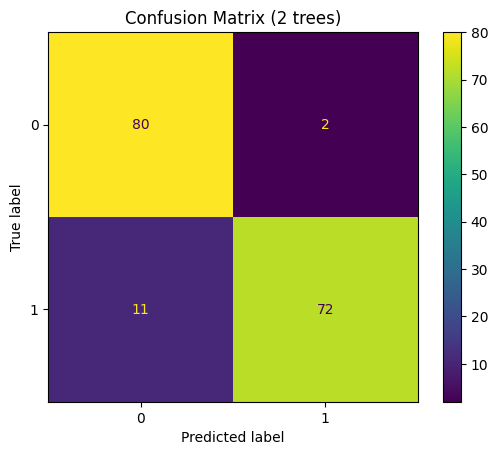

Precision: 0.972972972972973
Recall:    0.8674698795180723
F1-Score:  0.9171974522292994

Full Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92        82
           1       0.97      0.87      0.92        83

    accuracy                           0.92       165
   macro avg       0.93      0.92      0.92       165
weighted avg       0.93      0.92      0.92       165


When accuracy is NOT suitable:
  - Imbalanced datasets (e.g., 95% class 0, 5% class 1):
    a model predicting all zeros gets 95% accuracy but is useless.
  - When the cost of False Negatives vs False Positives differs greatly
    (e.g., medical diagnosis: missing a disease is worse than a false alarm).
  In such cases, precision, recall, and F1-score are more informative.



In [26]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, classification_report
)

y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.title("Confusion Matrix (2 trees)")
plt.show()

# Metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:   ", recall_score(y_test, y_pred))
print("F1-Score: ", f1_score(y_test, y_pred))
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred))

print("""
When accuracy is NOT suitable:
  - Imbalanced datasets (e.g., 95% class 0, 5% class 1):
    a model predicting all zeros gets 95% accuracy but is useless.
  - When the cost of False Negatives vs False Positives differs greatly
    (e.g., medical diagnosis: missing a disease is worse than a false alarm).
  In such cases, precision, recall, and F1-score are more informative.
""")

### Task 5: Accuracy vs Number of Trees (2–15)

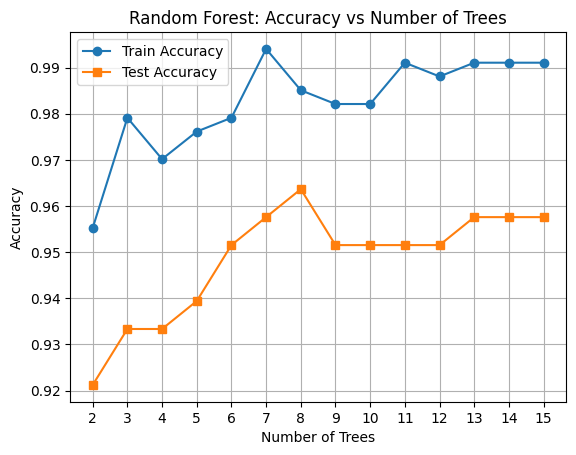


Observation:
  - Training accuracy tends to stay high or slightly decrease.
  - Testing accuracy generally improves as more trees are added,
    then stabilizes — more trees reduce variance (overfitting).



In [27]:
train_accs, test_accs = [], []
tree_range = range(2, 16)

for n in tree_range:
    rf = RandomForestClassifier(
        n_estimators=n, criterion="entropy",
        max_features="sqrt", max_samples=0.8,
        random_state=0
    )
    rf.fit(X_train, y_train)
    train_accs.append(rf.score(X_train, y_train))
    test_accs.append(rf.score(X_test, y_test))

plt.plot(list(tree_range), train_accs, marker="o", label="Train Accuracy")
plt.plot(list(tree_range), test_accs,  marker="s", label="Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs Number of Trees")
plt.xticks(list(tree_range))
plt.legend()
plt.grid(True)
plt.show()

print("""
Observation:
  - Training accuracy tends to stay high or slightly decrease.
  - Testing accuracy generally improves as more trees are added,
    then stabilizes — more trees reduce variance (overfitting).
""")

### Task 6: Decision Surface for Different Number of Trees

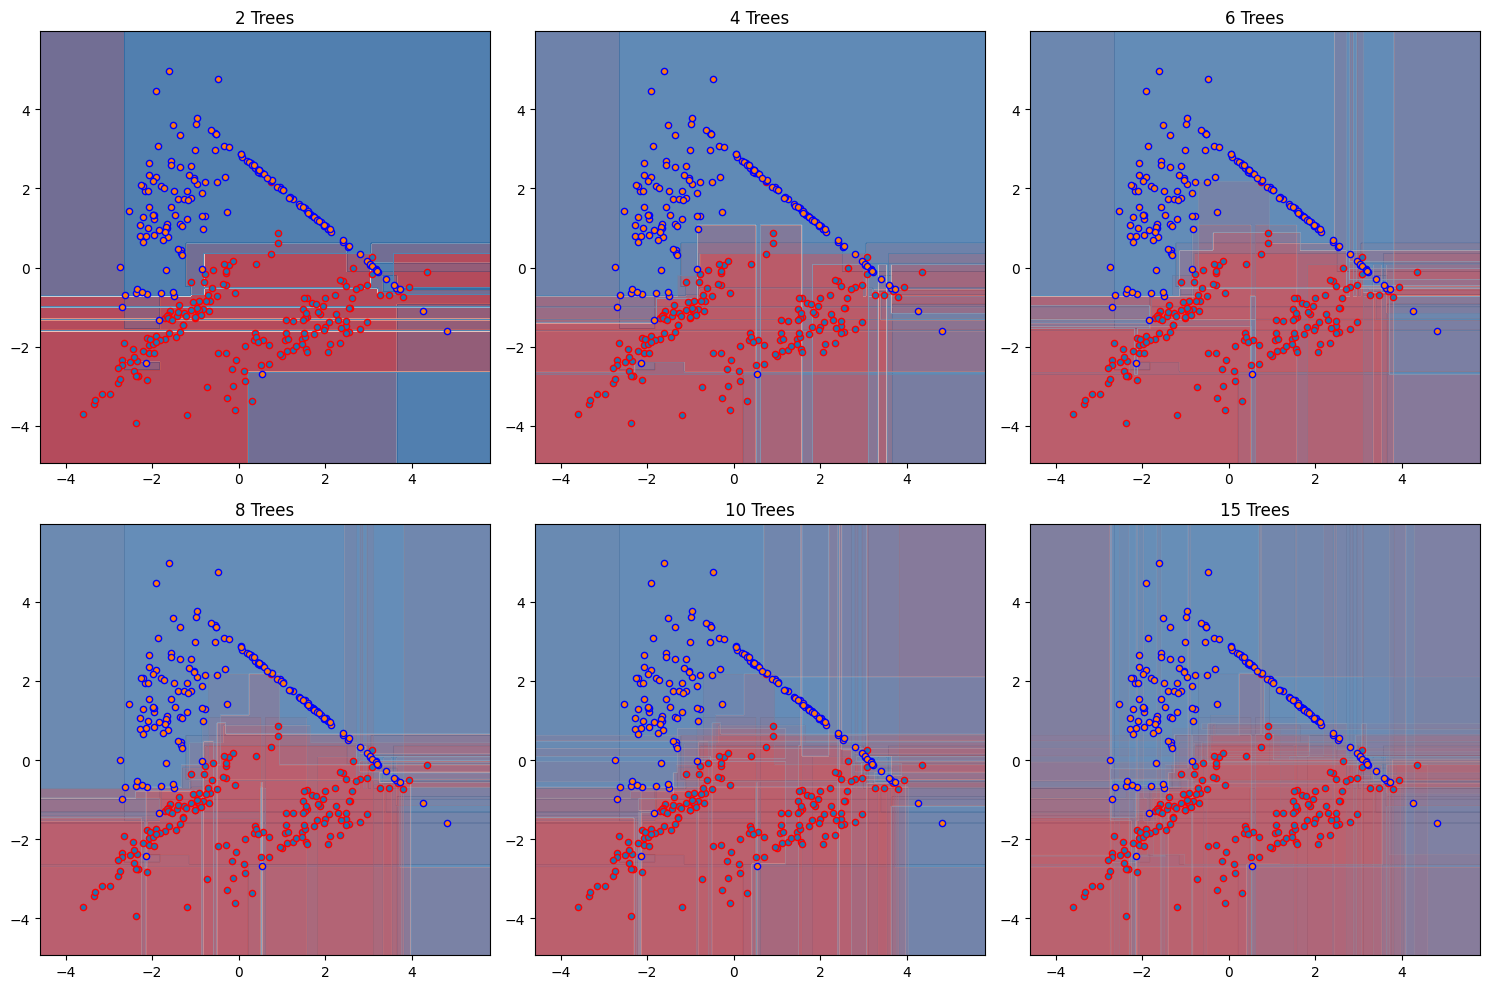


Pattern:
  - With fewer trees, the decision boundary is irregular and noisy.
  - As the number of trees increases, the boundary smooths out
    and becomes more stable, reducing variance.



In [28]:
from matplotlib.colors import ListedColormap

def plot_decision_surface(clf, X_train, y_train, title):
    cmap = plt.cm.RdBu
    plot_step = 0.02
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, plot_step),
        np.arange(y_min, y_max, plot_step)
    )

    if hasattr(clf, 'estimators_'):
        estimator_alpha = 1.0 / len(clf.estimators_)
        for tree in clf.estimators_:
            Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            plt.contourf(xx, yy, Z, alpha=estimator_alpha, cmap=cmap)
    else:
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.5, cmap=cmap)

    colors = ["r", "b"]
    for c in np.unique(y_train):
        plt.scatter(
            [X_train[i, 0] for i in np.where(y_train == c)[0]],
            [X_train[i, 1] for i in np.where(y_train == c)[0]],
            edgecolor=colors[c], s=20
        )
    plt.title(title)


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
tree_counts = [2, 4, 6, 8, 10, 15]

for ax, n in zip(axes.ravel(), tree_counts):
    rf = RandomForestClassifier(
        n_estimators=n, criterion="entropy",
        max_features="sqrt", max_samples=0.8,
        random_state=0
    )
    rf.fit(X_train, y_train)
    plt.sca(ax)
    plot_decision_surface(rf, X_train, y_train, f"{n} Trees")

plt.tight_layout()
plt.show()

print("""
Pattern:
  - With fewer trees, the decision boundary is irregular and noisy.
  - As the number of trees increases, the boundary smooths out
    and becomes more stable, reducing variance.
""")

### 1.2.3 SVM - Linear Kernel

In [29]:
from sklearn import svm

clf_svm_linear = svm.SVC(kernel="linear", C=100)
clf_svm_linear.fit(X_train, y_train)

print("Training Accuracy:", clf_svm_linear.score(X_train, y_train))
print("Testing Accuracy: ", clf_svm_linear.score(X_test, y_test))

Training Accuracy: 0.8895522388059701
Testing Accuracy:  0.896969696969697


### Task 7: Decision Surface for Linear SVM

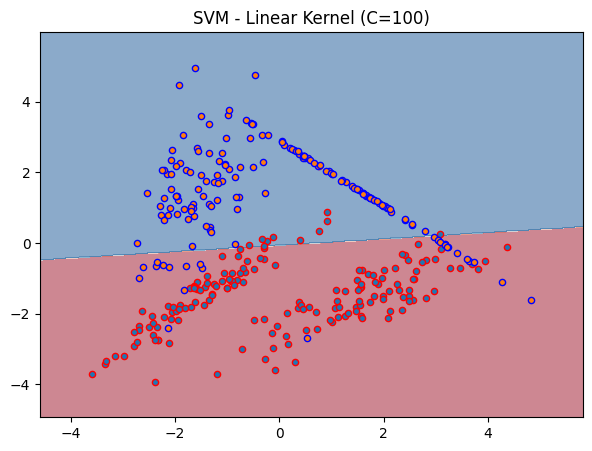

In [30]:
plt.figure(figsize=(7, 5))
plot_decision_surface(clf_svm_linear, X_train, y_train, "SVM - Linear Kernel (C=100)")
plt.show()

### Task 8: SVM with RBF Kernel

Training Accuracy: 0.9701492537313433
Testing Accuracy:  0.9636363636363636


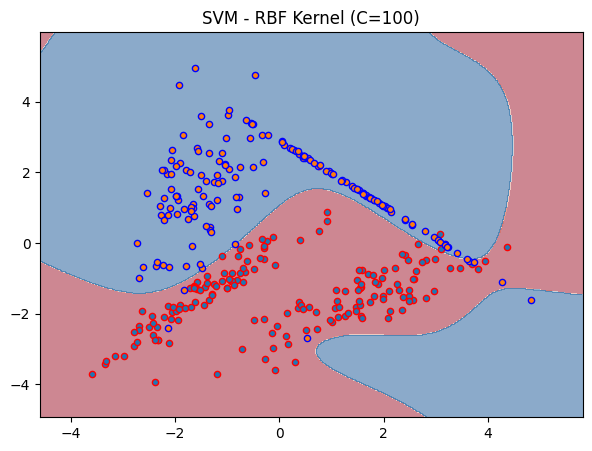


Observation:
  RBF kernel produces a non-linear (curved) decision boundary,
  unlike the straight line from the linear kernel.
  It can capture more complex patterns in the data.



In [31]:
clf_svm_rbf = svm.SVC(kernel="rbf", C=100)
clf_svm_rbf.fit(X_train, y_train)

print("Training Accuracy:", clf_svm_rbf.score(X_train, y_train))
print("Testing Accuracy: ", clf_svm_rbf.score(X_test, y_test))

plt.figure(figsize=(7, 5))
plot_decision_surface(clf_svm_rbf, X_train, y_train, "SVM - RBF Kernel (C=100)")
plt.show()

print("""
Observation:
  RBF kernel produces a non-linear (curved) decision boundary,
  unlike the straight line from the linear kernel.
  It can capture more complex patterns in the data.
""")

### Task 9: RBF SVM with Different C Values (0.5, 1, 100, 1000)

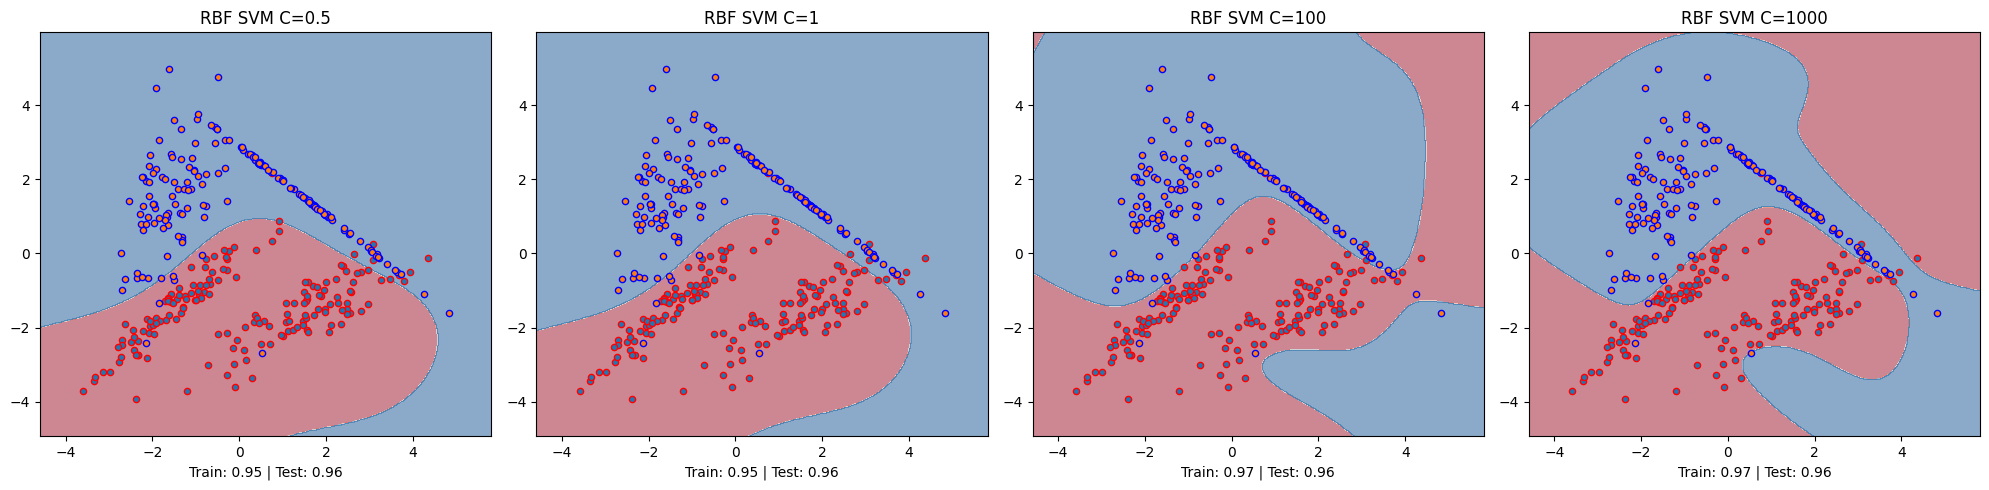


Observation:
  - Small C (0.5, 1): Wider margin, smoother/simpler boundary, may underfit.
  - Large C (100, 1000): Narrower margin, more complex boundary, may overfit.
  C controls the trade-off between maximizing margin and minimizing
  classification error on training data.



In [32]:
C_values = [0.5, 1, 100, 1000]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, C in zip(axes, C_values):
    clf_c = svm.SVC(kernel="rbf", C=C)
    clf_c.fit(X_train, y_train)
    plt.sca(ax)
    plot_decision_surface(clf_c, X_train, y_train, f"RBF SVM C={C}")
    ax.set_xlabel(f"Train: {clf_c.score(X_train, y_train):.2f} | Test: {clf_c.score(X_test, y_test):.2f}")

plt.tight_layout()
plt.show()

print("""
Observation:
  - Small C (0.5, 1): Wider margin, smoother/simpler boundary, may underfit.
  - Large C (100, 1000): Narrower margin, more complex boundary, may overfit.
  C controls the trade-off between maximizing margin and minimizing
  classification error on training data.
""")

---
## 1.3 Hyper-parameter Selection with GridSearchCV

In [33]:
from sklearn.model_selection import GridSearchCV

parameters = {"kernel": ("linear", "rbf"), "C": [1, 10, 100]}
svc = svm.SVC()
clf_grid = GridSearchCV(svc, parameters, cv=5)
clf_grid.fit(X_train, y_train)

print("Best Parameters:", clf_grid.best_params_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}


### Task 10: Exploring cv_results_

In [34]:
import pandas as pd

results_df = pd.DataFrame(clf_grid.cv_results_)

# Show the most informative columns
cols_to_show = [
    'param_kernel', 'param_C',
    'mean_test_score', 'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]
print(results_df[cols_to_show].sort_values('rank_test_score').to_string(index=False))

print("""
Explanation of key cv_results_ fields:
  - param_kernel / param_C : the hyperparameter combination tested
  - mean_test_score        : average cross-validation accuracy over 5 folds
  - std_test_score         : standard deviation of the CV scores (stability)
  - rank_test_score        : rank 1 = best performing combination
  - mean_fit_time          : average time to fit the model across folds
  - split0_test_score ..   : score on each individual fold
""")

param_kernel  param_C  mean_test_score  std_test_score  rank_test_score  mean_fit_time
         rbf       10         0.955224        0.021108                1       0.002505
         rbf      100         0.952239        0.011169                2       0.003344
         rbf        1         0.949254        0.022338                3       0.002701
      linear        1         0.892537        0.028941                4       0.006006
      linear      100         0.889552        0.030733                5       0.024871
      linear       10         0.886567        0.033507                6       0.005427

Explanation of key cv_results_ fields:
  - param_kernel / param_C : the hyperparameter combination tested
  - mean_test_score        : average cross-validation accuracy over 5 folds
  - std_test_score         : standard deviation of the CV scores (stability)
  - rank_test_score        : rank 1 = best performing combination
  - mean_fit_time          : average time to fit the model across